In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import sqrt

# -------------------------
# Sample data
# -------------------------

x = np.array([12, 15, 14, 10, 18, 20, 17, 16], dtype=float)

mean_x = np.mean(x)
var_x_sample = np.var(x, ddof=1)   # sample (unbiased) variance

print(f"mean = {mean_x:.4f}")
print(f"variance (sample, ddof=1) = {var_x_sample:.4f}")


mean = 15.2500
variance (sample, ddof=1) = 10.5000


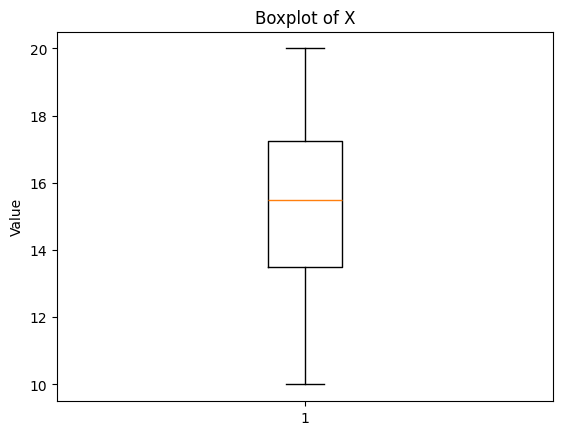

In [6]:

# =========================================================
# Draw Box-Plot
# =========================================================

plt.figure()
plt.boxplot(x, vert=True)
plt.title("Boxplot of X")
plt.ylabel("Value")
plt.show()


In [8]:

# Sample 1 (Old Packaging)
x1 = [
    3.6, 3.1, 3.8, 3.2, 3.5, 3.4, 3.0, 3.7, 3.3, 3.9,
    3.2, 3.6, 3.5, 3.1, 3.4, 3.8, 3.7, 3.3, 3.6, 3.2,
    3.9, 3.5, 3.1, 3.4, 3.8, 3.2, 3.7, 3.3, 3.6, 3.4,
    3.1, 3.5, 3.9, 3.2, 3.7, 3.4, 3.6, 3.3, 3.8, 3.0,
    3.5, 3.4, 3.2, 3.7, 3.6, 3.1, 3.8, 3.3, 3.5, 3.4
]

# Sample 2 (New Packaging)
x2 = [
    2.8, 2.9, 3.1, 2.7, 2.6, 3.0, 2.9, 2.8, 3.2, 2.7,
    2.9, 3.0, 2.6, 2.8, 3.1, 2.9, 2.7, 3.0, 2.8, 2.9,
    3.1, 2.6, 2.7, 2.9, 3.0, 2.8, 2.9, 3.2, 2.7, 2.8,
    2.9, 3.0, 2.6, 2.7, 3.1, 2.8, 2.9, 2.7, 3.0, 2.8,
    2.9, 3.1, 2.6, 2.7, 2.8, 2.9, 3.0, 2.8, 2.7, 3.1,
    2.9, 2.6, 2.8, 2.7, 3.0, 2.9, 2.8, 2.7, 3.1, 2.9
]

n1, n2 = len(x1), len(x2)

xbar1, xbar2 = np.mean(x1), np.mean(x2)
s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

# Standard error
se = sqrt((s1**2)/n1 + (s2**2)/n2)

# Z statistic
z = (xbar1 - xbar2) / se

# One-sided p-value (right tail)
p_value = 1 - stats.norm.cdf(z)

# Significance level
alpha = 0.05

# Critical value for right-tailed test
z_crit = stats.norm.ppf(1 - alpha)

print("=== 1-sided 2-sample Z-test (H1: mu1 > mu2) ===")
print(f"xbar1 = {xbar1:.4f}, xbar2 = {xbar2:.4f}")
print(f"SE = {se:.4f}")
print(f"z = {z:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"critical value = {z_crit:.4f}")

# Decision
print("Reject H0 (critical value method)?",
      "YES" if z > z_crit else "NO")

print("Reject H0 (p-value method)?",
      "YES" if p_value < alpha else "NO")


=== 1-sided 2-sample Z-test (H1: mu1 > mu2) ===
xbar1 = 3.4560, xbar2 = 2.8600
SE = 0.0098
z = 60.5513
p-value = 0.000000
critical value = 1.6449
Reject H0 (critical value method)? YES
Reject H0 (p-value method)? YES


In [10]:
# -----------------------------
# Example data (2 proportions test)
# -----------------------------

x1, x2 = 45, 31
n1, n2 = 500, 520

# Hypotheses
# H0: p1 = p2
# H1: p1 > p2

p1, p2 = x1/n1, x2/n2
p_hat = (x1 + x2) / (n1 + n2)

# Standard error (pooled)
se = sqrt(p_hat * (1 - p_hat) * (1/n1 + 1/n2))

# Z statistic
z = (p1 - p2) / se

# One-sided p-value (right tail)
p_value = 1 - stats.norm.cdf(z)

# Significance level
alpha = 0.05

# Critical value for right-tailed test
z_crit = stats.norm.ppf(1 - alpha)

print("=== One-sided Two-Proportion Z-test (H1: p1 > p2) ===")
print(f"p1 = {p1:.4f}, p2 = {p2:.4f}")
print(f"z = {z:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"critical value = {z_crit:.4f}")

print("Reject H0 (critical value method)?",
      "YES" if z > z_crit else "NO")

print("Reject H0 (p-value method)?",
      "YES" if p_value < alpha else "NO")


=== One-sided Two-Proportion Z-test (H1: p1 > p2) ===
p1 = 0.0900, p2 = 0.0596
z = 1.8473
p-value = 0.032349
critical value = 1.6449
Reject H0 (critical value method)? YES
Reject H0 (p-value method)? YES


In [13]:
from ortools.linear_solver import pywraplp


def LinearProgrammingExample():
    """Linear programming sample."""

    # Instantiate a Glop solver (PDLP in your screenshot).
    solver = pywraplp.Solver.CreateSolver("PDLP")
    if not solver:
        return

    # Create the two variables and let them take on any non-negative value.
    x = solver.NumVar(0, solver.infinity(), "x")
    y = solver.NumVar(0, solver.infinity(), "y")

    print("Number of variables =", solver.NumVariables())

    # Constraint 0: x + 2y <= 14.
    solver.Add(x + 2 * y <= 14.0)

    # Constraint 1: 3x - y >= 0.
    solver.Add(3 * x - y >= 0.0)

    # Constraint 2: x - y <= 2.
    solver.Add(x - y <= 2.0)

    print("Number of constraints =", solver.NumConstraints())

    # Objective function: 3x + 4y.
    solver.Maximize(3 * x + 4 * y)

    # Solve the system.
    print(f"Solving with {solver.SolverVersion()}")
    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Solution:")
        print(f"Objective value = {solver.Objective().Value():.1f}")
        print(f"x = {x.solution_value():.1f}")
        print(f"y = {y.solution_value():.1f}")
    else:
        print("The problem does not have an optimal solution.")


# print("\nAdvanced usage:")
# print(f"Problem solved in {solver.wall_time():d} milliseconds")
# print(f"Problem solved in {solver.iterations():d} iterations")

# Run the example
LinearProgrammingExample()


Number of variables = 2
Number of constraints = 3
Solving with PDLP Solver
Solution:
Objective value = 34.0
x = 6.0
y = 4.0
